In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.options.display.float_format = '{:.2f}'.format

HS_data = pd.read_csv('AICPA_regressionAnalysisData.csv')

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
HS_data['date'] = pd.to_datetime(HS_data['date'])

display(HS_data)

,type,date,revenue,production,coolDD,heatDD
0,dt4training,2011-01-31,23304096,659640,0,1021
1,dt4training,2011-02-28,24552000,686144,0,794
2,dt4training,2011-03-31,14804728,416464,0,714
3,dt4training,2011-04-30,11265320,324456,1,354
4,dt4training,2011-05-31,5945904,151104,72,114
5,dt4training,2011-06-30,10379712,479264,239,4
6,dt4training,2011-07-31,13617528,708472,486,0
7,dt4training,2011-08-31,14092512,687728,346,0
8,dt4training,2011-09-30,12085472,567424,195,19
9,dt4training,2011-10-31,11957032,392328,24,223


In [ ]:
# a dummy = 1 when the row is in that season, else 0
# winter is months 12, 1, 2
HS_data['winter_DV'] = np.where(HS_data['date'].dt.month.isin([12,1,2]),1,0)
# fall is months 9, 10, 11
HS_data['fall_DV']   = np.where(HS_data['date'].dt.month.isin([9,10,11]),1,0)

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,winter_DV,fall_DV
0,dt4training,2011-01-31,23304096,659640,0,1021,1,0
1,dt4training,2011-02-28,24552000,686144,0,794,1,0
2,dt4training,2011-03-31,14804728,416464,0,714,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,1
9,dt4training,2011-10-31,11957032,392328,24,223,0,1


In [ ]:
#interaction tern = independent variable * dummy
# this lets the production slope change in that season, not just the intercept
HS_data['winter_interaction'] = HS_data['production'] * HS_data['winter_DV']
HS_data['fall_interaction']   = HS_data['production'] * HS_data['fall_DV']

display(HS_data)

,type,date,revenue,production,coolDD,heatDD,winter_DV,fall_DV,winter_interaction,fall_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,1,0,659640,0
1,dt4training,2011-02-28,24552000,686144,0,794,1,0,686144,0
2,dt4training,2011-03-31,14804728,416464,0,714,0,0,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,1,0,567424
9,dt4training,2011-10-31,11957032,392328,24,223,0,1,0,392328


In [ ]:
# fit the models on the training years and judge them on the unseen testing year
dt4training = HS_data.loc[HS_data['type']=='dt4training']  # 2011-2013
dt4testing  = HS_data.loc[HS_data['type']=='dt4testing']   # 2014

display(dt4training)
display(dt4testing)

,type,date,revenue,production,coolDD,heatDD,winter_DV,fall_DV,winter_interaction,fall_interaction
0,dt4training,2011-01-31,23304096,659640,0,1021,1,0,659640,0
1,dt4training,2011-02-28,24552000,686144,0,794,1,0,686144,0
2,dt4training,2011-03-31,14804728,416464,0,714,0,0,0,0
3,dt4training,2011-04-30,11265320,324456,1,354,0,0,0,0
4,dt4training,2011-05-31,5945904,151104,72,114,0,0,0,0
5,dt4training,2011-06-30,10379712,479264,239,4,0,0,0,0
6,dt4training,2011-07-31,13617528,708472,486,0,0,0,0,0
7,dt4training,2011-08-31,14092512,687728,346,0,0,0,0,0
8,dt4training,2011-09-30,12085472,567424,195,19,0,1,0,567424
9,dt4training,2011-10-31,11957032,392328,24,223,0,1,0,392328


,type,date,revenue,production,coolDD,heatDD,winter_DV,fall_DV,winter_interaction,fall_interaction
36,dt4testing,2014-01-31,19228840,606400,0,1123,1,0,606400,0
37,dt4testing,2014-02-28,26792280,714128,0,938,1,0,714128,0
38,dt4testing,2014-03-31,19935840,805600,0,866,0,0,0,0
39,dt4testing,2014-04-30,13468000,375856,0,412,0,0,0,0
40,dt4testing,2014-05-31,7344128,279296,49,88,0,0,0,0
41,dt4testing,2014-06-30,11196216,517600,230,0,0,0,0,0
42,dt4testing,2014-07-31,13929472,749472,380,0,0,0,0,0
43,dt4testing,2014-08-31,12352176,663432,322,0,0,0,0,0
44,dt4testing,2014-09-30,12628944,701656,178,14,0,1,0,701656
45,dt4testing,2014-10-31,9361000,411728,24,166,0,1,0,411728


In [ ]:
# y is what we predict (revenue), x is what we predict it from
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,['production','winter_DV','winter_interaction']]
x = sm.add_constant(x)   # adds the intercept term

# fit the regression and show the coefficients
model1 = sm.OLS(y,x).fit()

model1.params

,0
const,5629257.08
production,13.51
winter_DV,-201742.73
winter_interaction,14.16


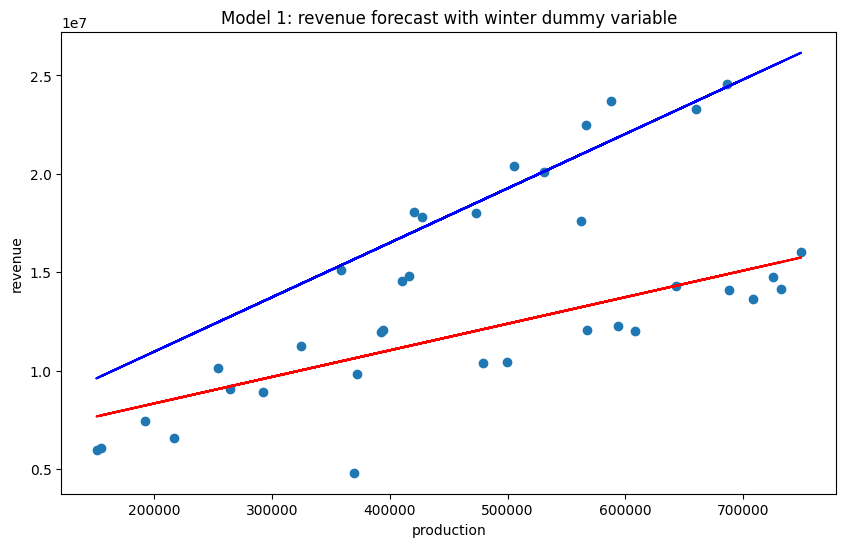

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Model 1: revenue forecast with winter dummy variable')
plt.xlabel('production')
plt.ylabel('revenue')

# step 1: scatter the actual training points
plt.scatter(dt4training['production'],dt4training['revenue'])

# step 2: pull the four coefficients out of the model
intercept, production_coefficient, winter_DV_intercept, winter_coefficient = model1.params

# step 3: build one line for non-winter and one for winter
non_winter_line = intercept + production_coefficient * dt4training['production']
winter_line = (intercept + winter_DV_intercept) + (production_coefficient + winter_coefficient) * dt4training['production']

# step 4: draw both lines (red = non-winter, blue = winter)
plt.plot(dt4training['production'], non_winter_line, color='red')
plt.plot(dt4training['production'], winter_line, color='blue')

In [ ]:
#Model 2
# adds heatDD (heating demand) and uses the fall dummy + fall interaction
y = dt4training.loc[:,'revenue']
x = dt4training.loc[:,['production','heatDD','fall_DV','fall_interaction']]
x = sm.add_constant(x)

model2 = sm.OLS(y,x).fit()

model2.params

,0
const,2487346.50
production,17.50
heatDD,10340.73
fall_DV,-4993905.85
fall_interaction,7.08


In [ ]:
# copy the test rows so we can add prediction columns to them
model_assessment = dt4testing.copy()

# Model 1: build the same x columns on the test set, then predict
x_test1 = dt4testing.loc[:,['production','winter_DV','winter_interaction']]
x_test1 = sm.add_constant(x_test1)
model_assessment['model1_predicted_revenue'] = model1.predict(x_test1)
# absolute percentage error for each month
model_assessment['model1_abs_pct_error'] = abs(
    (model_assessment['revenue'] - model_assessment['model1_predicted_revenue'])/model_assessment['revenue']
    )

# Model 2: same steps with its own predictors
x_test2 = dt4testing.loc[:,['production','heatDD','fall_DV','fall_interaction']]
x_test2 = sm.add_constant(x_test2)
model_assessment['model2_predicted_revenue'] = model2.predict(x_test2)
model_assessment['model2_abs_pct_error'] = abs(
    (model_assessment['revenue'] - model_assessment['model2_predicted_revenue'])/model_assessment['revenue']
    )

display(model_assessment[['date','revenue',
                          'model1_predicted_revenue','model1_abs_pct_error',
                          'model2_predicted_revenue','model2_abs_pct_error']])

,date,revenue,model1_predicted_revenue,model1_abs_pct_error,model2_predicted_revenue,model2_abs_pct_error
36,2014-01-31,19228840,22205317.42,0.15,24713706.00,0.29
37,2014-02-28,26792280,25185922.91,0.06,24686216.29,0.08
38,2014-03-31,19935840,16509348.78,0.17,25542703.03,0.28
39,2014-04-30,13468000,10705408.70,0.21,13326273.04,0.01
40,2014-05-31,7344128,9401310.32,0.28,8285802.61,0.13
41,2014-06-30,11196216,12619743.01,0.13,11546813.95,0.03
42,2014-07-31,13929472,15751307.84,0.13,15605231.33,0.12
43,2014-08-31,12352176,14589288.11,0.18,14099287.40,0.14
44,2014-09-30,12628944,15105525.23,0.20,14885987.84,0.18
45,2014-10-31,9361000,11189880.71,0.20,9330905.47,0.00


In [ ]:
# MAPE = the mean of the per-month absolute percentage errors, lower is better
model1_mape = model_assessment['model1_abs_pct_error'].mean()
model2_mape = model_assessment['model2_abs_pct_error'].mean()

print('Model 1 (Winter Seasonal)      MAPE:', round(model1_mape*100,2), '%')
print('Model 2 (Fall + Heating-Demand) MAPE:', round(model2_mape*100,2), '%')

Model 1 (Winter Seasonal)      MAPE: 15.9 %
Model 2 (Fall + Heating-Demand) MAPE: 11.75 %


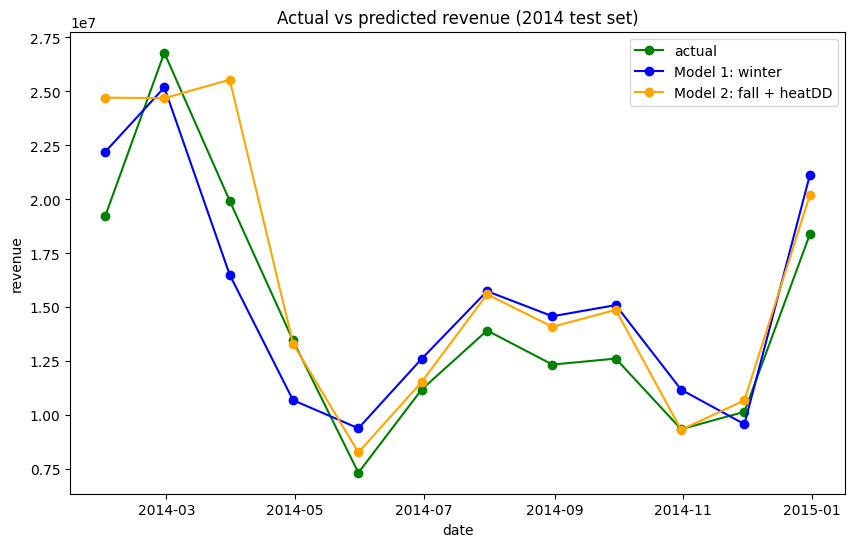

In [ ]:
plt.figure(figsize=(10,6))

plt.title('Actual vs predicted revenue (2014 test set)')
plt.xlabel('date')
plt.ylabel('revenue')

# green = real revenue, blue = Model 1, orange = Model 2
plt.plot(model_assessment['date'], model_assessment['revenue'], marker='o', color='green', label='actual')
plt.plot(model_assessment['date'], model_assessment['model1_predicted_revenue'], marker='o', color='blue', label='Model 1: winter')
plt.plot(model_assessment['date'], model_assessment['model2_predicted_revenue'], marker='o', color='orange', label='Model 2: fall + heatDD')

plt.legend()

#Memo:Recommended Forecasting Model
To: H&S Management
From: Data Analytics

I built two models on 2011 to 2013 data and tested them on unseen 2014 months. Both use a seasonal dummy and an interaction term.

Model 1 uses production with a winter dummy. Model 2 adds heating degree days with a fall dummy.
Model 2 wins. Its test MAPE is 11.75 percent versus 15.90 percent for Model 1, and it tracks the actual 2014 line more closely because it reads how cold each month really is through heatDD.

Recommendation: Use Model 2. Caution: the test is only one year, so re-check as new data arrives.